In [1]:
from shapely import wkt
from shapely.geometry import GeometryCollection, LineString, MultiPoint, Point, Polygon, MultiPolygon
import geopandas as gpd
import pandas as pd
from mypythonlib import myfunctions
import xarray as xr
import numpy as np

# Transforming  and preparing the original dataframe for sentinel download

First, only the wind and insect occurrences are selected, since a purely spatial classification between these two is attempted.

---

1. Loading original dataframe and selection of all disturbances after 2016 - because Sentinel was only put into service in 2016.
2. Selection of all wind occurrences and insect infestations. Insects include bark beetles, defiliators, biotics and abiotics.
3. Transforming Pandas dataframe zu GeoPandas dataframe
4. Resolving the multipolygons into smaller polygons - determining the centre and bounding box (to give this data to Minicuber)
5. Split large Polygon into smaller tiles

In [2]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

# Step 1: Read the CSV file into a DataFrame
df = pd.read_csv("/Net/Groups/BGI/work_2/ForExD/USDA/tables/CONUS_Region8_dissolved.csv")

# Step 2: Convert the WKT geometries to shapely geometries
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Optionally, set the coordinate reference system (CRS) if it's not already set
gdf.set_crs(epsg=4326, inplace=True)

# Filter for disturbances recorded between 2016 and 2020
gdf_sentile_timeframe = gdf[(gdf['SURVEY_YEAR'] > 2016) & (gdf['SURVEY_YEAR'] <= 2020)]
print(f"From 2016 to 2020, there were {gdf_sentile_timeframe.shape[0]} disturbances recorded by the USDA in Region 8.")

# Filter out specific disturbance types
excluded_types = ['fire', 'other', 'drought', 'multi_damage', 'other_abiotic', 'other_biotic']
rslt_df = gdf_sentile_timeframe[~gdf_sentile_timeframe['DCA_ID'].isin(excluded_types)]

print(f"From 2016 to 2020, there were multiple wind and insect disturbances recorded by the USDA in Region 8.")

# Display the first 4 rows of the filtered GeoDataFrame
rslt_df.head(4)


From 2016 to 2020, there were 32 disturbances recorded by the USDA in Region 8.
From 2016 to 2020, there were multiple wind and insect disturbances recorded by the USDA in Region 8.


,Unnamed: 0,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE
16,16,bark_beetle,2017,"MULTIPOLYGON (((-82.69315 29.16785, -82.69322 ...",8,Mortality,2,11003,1,No Data,shortleaf pine,-1.0
17,17,bark_beetle,2018,"MULTIPOLYGON (((-82.32171 29.30769, -82.32136 ...",8,Mortality,2,11003,1,Moderate (11-29%),shortleaf pine,110.0
18,18,bark_beetle,2019,"MULTIPOLYGON (((-94.16455 30.44747, -94.16436 ...",8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0
19,19,bark_beetle,2020,"MULTIPOLYGON (((-81.92146 29.79954, -81.92043 ...",8,Mortality,2,11030,1,Light (4-10%),loblolly pine,131.0


<Axes: >

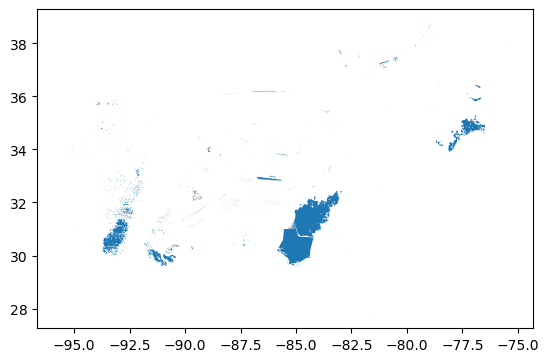

In [3]:
rslt_df.plot()